# Assignment No. 1
Name: Avishkar Dinesh Chothwe
PRN :22310789
Roll No: 382028

Q. Gaussian Mixture Model (GMM) Implementation
A probabilistic generative model using the Expectation-Maximization (EM) algorithm

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from typing import Tuple, Optional

In [48]:
class GaussianMixtureModel:
    """
    Gaussian Mixture Model for clustering and density estimation.

    The model assumes data is generated from K Gaussian distributions:
    p(x) = Σ π_k * N(x | μ_k, Σ_k)

    Parameters are learned using the EM algorithm.
    """
    def __init__(self, n_components: int = 3, max_iter: int = 100, tol: float = 1e-4, random_state: Optional[int] = None):
        """
        Initialize GMM.

        Args:
            n_components: Number of Gaussian components (K)
            max_iter: Maximum number of EM iterations
            tol: Convergence threshold for log-likelihood
            random_state: Random seed for reproducibility
        """
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # Model parameters (learned during fit)
        self.weights_ = None  # π_k: mixing coefficients
        self.means_ = None    # μ_k: component means
        self.covariances_ = None  # Σ_k: component covariances

        # Training history
        self.log_likelihoods_ = []
        self.converged_ = False

In [49]:
    def _initialize_parameters(self, X: np.ndarray) -> None:
        """Initialize parameters using k-means++ strategy."""
        n_samples, n_features = X.shape

        if self.random_state is not None:
            np.random.seed(self.random_state)
        # Initialize weights uniformly
        self.weights_ = np.ones(self.n_components) / self.n_components

        # Initialize means using k-means++ approach
        self.means_ = np.zeros((self.n_components, n_features))

        # First center randomly
        self.means_[0] = X[np.random.choice(n_samples)]

        # Remaining centers using k-means++ (farther points more likely)
        for k in range(1, self.n_components):
            distances = np.min([np.sum((X - self.means_[j])**2, axis=1)
                               for j in range(k)], axis=0)
            probabilities = distances / distances.sum()
            self.means_[k] = X[np.random.choice(n_samples, p=probabilities)]

        # Initialize covariances as identity matrices scaled by data variance
        self.covariances_ = np.array([np.cov(X.T) + np.eye(n_features) * 1e-6
                                     for _ in range(self.n_components)])

In [50]:
    def _e_step(self, X: np.ndarray) -> np.ndarray:
        """
        E-step: Compute responsibilities (posterior probabilities).

        γ(z_nk) = p(z_k = 1 | x_n) = π_k * N(x_n | μ_k, Σ_k) / Σ_j π_j * N(x_n | μ_j, Σ_j)

        Returns:
            responsibilities: (n_samples, n_components) array
        """
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))

        # Compute weighted likelihood for each component
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * multivariate_normal.pdf(
                X, mean=self.means_[k], cov=self.covariances_[k]
            )

        # Normalize to get probabilities (avoid division by zero)
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        responsibilities_sum[responsibilities_sum == 0] = 1e-10
        responsibilities /= responsibilities_sum

        return responsibilities

In [51]:
    def _m_step(self, X: np.ndarray, responsibilities: np.ndarray) -> None:
        """
        M-step: Update parameters to maximize expected log-likelihood.

        Updates:
            - π_k = N_k / N
            - μ_k = (1/N_k) * Σ_n γ(z_nk) * x_n
            - Σ_k = (1/N_k) * Σ_n γ(z_nk) * (x_n - μ_k)(x_n - μ_k)^T
        """
        n_samples, n_features = X.shape

        # Effective number of points assigned to each component
        N_k = responsibilities.sum(axis=0)

        # Update mixing coefficients
        self.weights_ = N_k / n_samples

        # Update means
        self.means_ = (responsibilities.T @ X) / N_k[:, np.newaxis]

        # Update covariances
        for k in range(self.n_components):
            diff = X - self.means_[k]
            weighted_diff = responsibilities[:, k:k+1] * diff
            self.covariances_[k] = (weighted_diff.T @ diff) / N_k[k]

            # Add small regularization to prevent singular matrices
            self.covariances_[k] += np.eye(n_features) * 1e-6

In [52]:
    def _compute_log_likelihood(self, X: np.ndarray) -> float:
        """Compute log-likelihood: log p(X | θ) = Σ_n log Σ_k π_k * N(x_n | μ_k, Σ_k)"""
        n_samples = X.shape[0]
        log_likelihood = 0

        for n in range(n_samples):
            sample_likelihood = 0
            for k in range(self.n_components):
                sample_likelihood += self.weights_[k] * multivariate_normal.pdf(
                    X[n], mean=self.means_[k], cov=self.covariances_[k]
                )
            log_likelihood += np.log(sample_likelihood + 1e-10)

        return log_likelihood

In [53]:
    def fit(self, X: np.ndarray) -> 'GaussianMixtureModel':
        """
        Fit GMM to data using EM algorithm.

        Args:
            X: Training data (n_samples, n_features)

        Returns:
            self: Fitted model
        """
        self._initialize_parameters(X)

        prev_log_likelihood = -np.inf

        for iteration in range(self.max_iter):
            # E-step: compute responsibilities
            responsibilities = self._e_step(X)

            # M-step: update parameters
            self._m_step(X, responsibilities)

            # Compute log-likelihood for convergence check
            log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihoods_.append(log_likelihood)

            # Check convergence
            if abs(log_likelihood - prev_log_likelihood) < self.tol:
                self.converged_ = True
                print(f"Converged at iteration {iteration + 1}")
                break

            prev_log_likelihood = log_likelihood

            if (iteration + 1) % 10 == 0:
                print(f"Iteration {iteration + 1}, Log-likelihood: {log_likelihood:.2f}")

        if not self.converged_:
            print(f"Did not converge after {self.max_iter} iterations")

        return self

In [54]:
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict cluster labels (MAP estimate)."""
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)

In [55]:
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict cluster labels (MAP estimate)."""
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)

In [56]:
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict soft cluster assignments (responsibilities)."""
        return self._e_step(X)

In [57]:
    def sample(self, n_samples: int = 100) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate samples from the learned distribution.

        Returns:
            samples: Generated samples
            labels: Component labels for each sample
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Sample component labels according to mixing coefficients
        labels = np.random.choice(self.n_components, size=n_samples, p=self.weights_)

        # Sample from each component
        samples = np.zeros((n_samples, self.means_.shape[1]))
        for k in range(self.n_components):
            mask = labels == k
            n_k = mask.sum()
            if n_k > 0:
                samples[mask] = np.random.multivariate_normal(
                    self.means_[k], self.covariances_[k], size=n_k
                )

        return samples, labels

In [58]:
    def score(self, X: np.ndarray) -> float:
        """Compute average log-likelihood per sample."""
        return self._compute_log_likelihood(X) / X.shape[0]

In [59]:
def generate_synthetic_data(n_samples: int = 500, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """Generate synthetic data from a true mixture of 3 Gaussians."""
    np.random.seed(random_state)

    # True parameters
    true_means = np.array([[0, 0], [5, 5], [0, 5]])
    true_covs = [
        np.array([[1, 0.5], [0.5, 1]]),
        np.array([[1.5, -0.3], [-0.3, 1.5]]),
        np.array([[0.8, 0], [0, 0.8]])
    ]
    true_weights = np.array([0.3, 0.4, 0.3])

    # Generate samples
    labels = np.random.choice(3, size=n_samples, p=true_weights)
    X = np.zeros((n_samples, 2))

    for k in range(3):
        mask = labels == k
        n_k = mask.sum()
        X[mask] = np.random.multivariate_normal(true_means[k], true_covs[k], size=n_k)

    return X, labels

In [60]:
def plot_results(X: np.ndarray, true_labels: np.ndarray, gmm: GaussianMixtureModel):
    """Visualize GMM results."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Plot 1: True clustering
    ax = axes[0, 0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title('True Clustering', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='True Component')
    ax.grid(True, alpha=0.3)

    # Plot 2: GMM predictions
    ax = axes[0, 1]
    predicted_labels = gmm.predict(X)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=predicted_labels, cmap='viridis', alpha=0.6, s=30)

    # Plot Gaussian ellipses
    for k in range(gmm.n_components):
        mean = gmm.means_[k]
        cov = gmm.covariances_[k]

        # Compute eigenvalues and eigenvectors for ellipse
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2 std devs

        from matplotlib.patches import Ellipse
        ellipse = Ellipse(mean, width, height, angle=angle,
                         fill=False, edgecolor='red', linewidth=2, linestyle='--')
        ax.add_patch(ellipse)
        ax.plot(mean[0], mean[1], 'r*', markersize=15, markeredgecolor='black')

    ax.set_title('GMM Clustering (with 2σ ellipses)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='Predicted Component')
    ax.grid(True, alpha=0.3)

    # Plot 3: Log-likelihood convergence
    ax = axes[1, 0]
    ax.plot(gmm.log_likelihoods_, linewidth=2, color='navy')
    ax.set_title('Training Convergence', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-Likelihood')
    ax.grid(True, alpha=0.3)

    # Plot 4: Generated samples
    ax = axes[1, 1]
    generated_samples, generated_labels = gmm.sample(n_samples=500)
    scatter = ax.scatter(generated_samples[:, 0], generated_samples[:, 1],
                        c=generated_labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title('Samples Generated from Learned Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='Component')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig



Gaussian Mixture Model Implementation

1. Generating synthetic data from 3 Gaussians...
   Generated 500 samples with 2 features

2. Fitting GMM with EM algorithm...
Iteration 10, Log-likelihood: -1968.49
Converged at iteration 14

3. Learned Parameters:

   Mixing Coefficients (weights):
   Component 0: π_0 = 0.387
   Component 1: π_1 = 0.305
   Component 2: π_2 = 0.308

   Component Means:
   μ_0 = [4.90661963 5.16365827]
   μ_1 = [0.02994636 5.04488547]
   μ_2 = [0.06058712 0.06244964]

   Component Covariances:
   Σ_0 =
[[ 1.56994746 -0.06236035]
 [-0.06236035  1.19573346]]
   Σ_1 =
[[ 0.7015878  -0.01794915]
 [-0.01794915  0.95706012]]
   Σ_2 =
[[1.09514445 0.59750129]
 [0.59750129 1.10436558]]

4. Model Evaluation:
   Average log-likelihood: -3.937

5. Generating new samples from learned distribution...
   Generated 100 new samples

6. Creating visualizations...


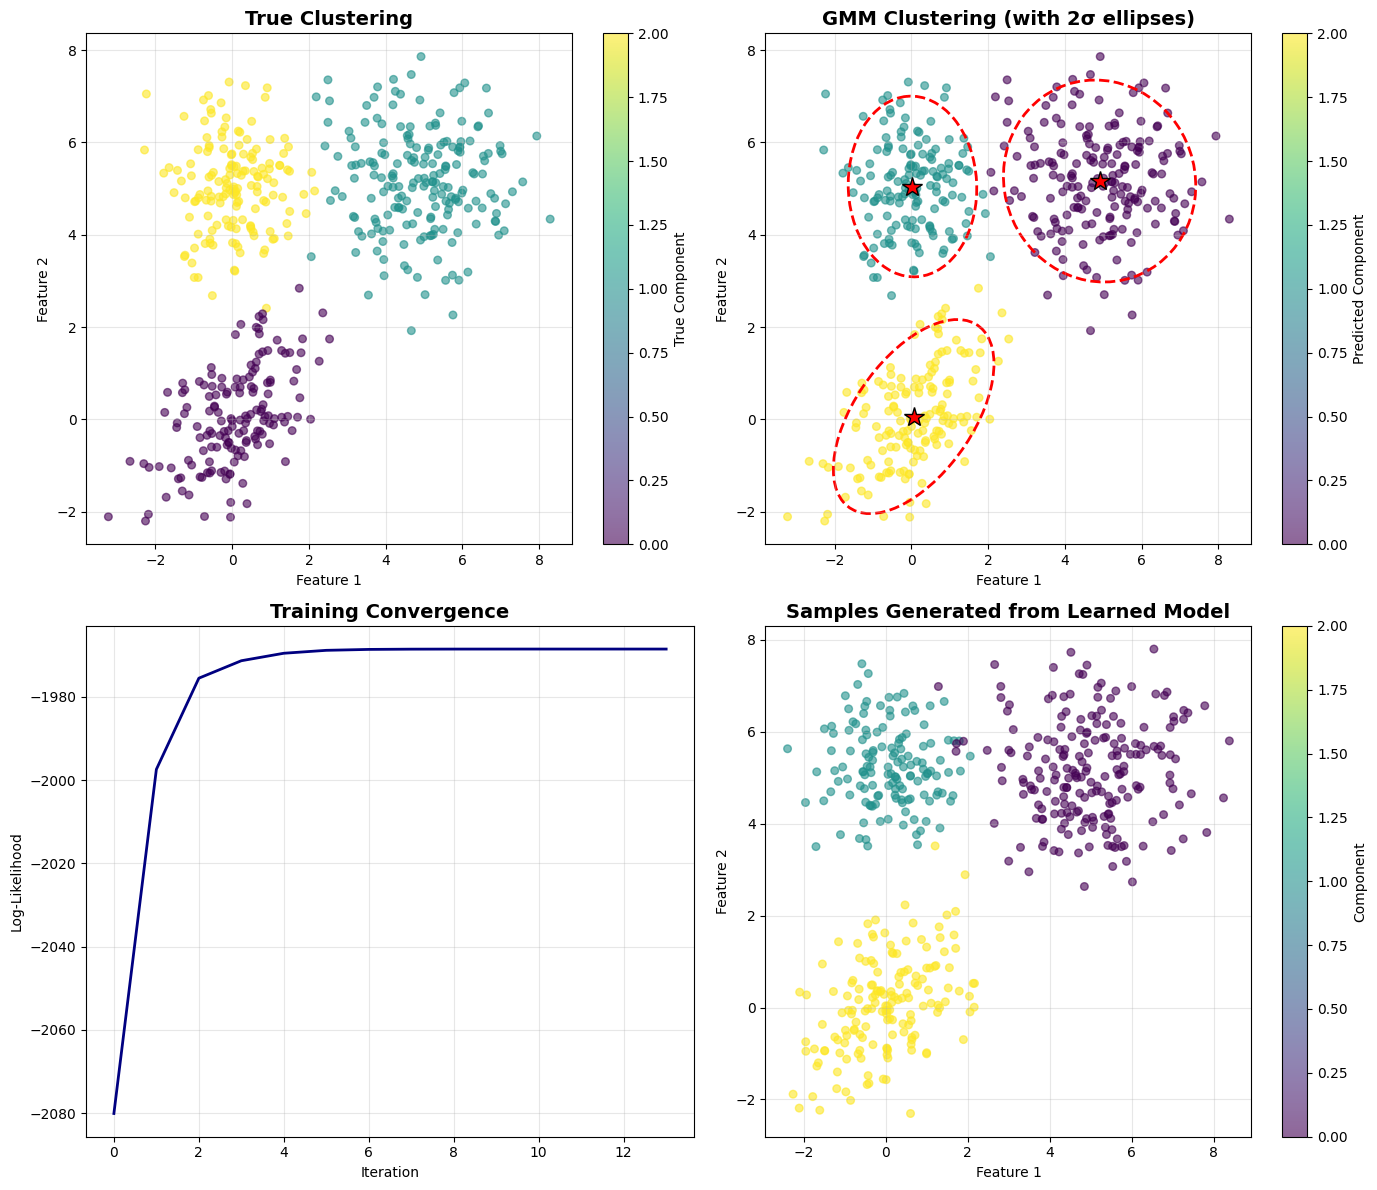


Done! GMM successfully trained and visualized.


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from typing import Tuple, Optional


class GaussianMixtureModel:
    """
    Gaussian Mixture Model for clustering and density estimation.

    The model assumes data is generated from K Gaussian distributions:
    p(x) = Σ π_k * N(x | μ_k, Σ_k)

    Parameters are learned using the EM algorithm.
    """

    def __init__(self, n_components: int = 3, max_iter: int = 100, tol: float = 1e-4, random_state: Optional[int] = None):
        """
        Initialize GMM.

        Args:
            n_components: Number of Gaussian components (K)
            max_iter: Maximum number of EM iterations
            tol: Convergence threshold for log-likelihood
            random_state: Random seed for reproducibility
        """
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        # Model parameters (learned during fit)
        self.weights_ = None  # π_k: mixing coefficients
        self.means_ = None    # μ_k: component means
        self.covariances_ = None  # Σ_k: component covariances

        # Training history
        self.log_likelihoods_ = []
        self.converged_ = False

    def _initialize_parameters(self, X: np.ndarray) -> None:
        """Initialize parameters using k-means++ strategy."""
        n_samples, n_features = X.shape

        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Initialize weights uniformly
        self.weights_ = np.ones(self.n_components) / self.n_components

        # Initialize means using k-means++ approach
        self.means_ = np.zeros((self.n_components, n_features))

        # First center randomly
        self.means_[0] = X[np.random.choice(n_samples)]

        # Remaining centers using k-means++ (farther points more likely)
        for k in range(1, self.n_components):
            distances = np.min([np.sum((X - self.means_[j])**2, axis=1)
                               for j in range(k)], axis=0)
            probabilities = distances / distances.sum()
            self.means_[k] = X[np.random.choice(n_samples, p=probabilities)]

        # Initialize covariances as identity matrices scaled by data variance
        self.covariances_ = np.array([np.cov(X.T) + np.eye(n_features) * 1e-6
                                     for _ in range(self.n_components)])

    def _e_step(self, X: np.ndarray) -> np.ndarray:
        """
        E-step: Compute responsibilities (posterior probabilities).

        γ(z_nk) = p(z_k = 1 | x_n) = π_k * N(x_n | μ_k, Σ_k) / Σ_j π_j * N(x_n | μ_j, Σ_j)

        Returns:
            responsibilities: (n_samples, n_components) array
        """
        n_samples = X.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))

        # Compute weighted likelihood for each component
        for k in range(self.n_components):
            responsibilities[:, k] = self.weights_[k] * multivariate_normal.pdf(
                X, mean=self.means_[k], cov=self.covariances_[k]
            )

        # Normalize to get probabilities (avoid division by zero)
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True)
        responsibilities_sum[responsibilities_sum == 0] = 1e-10
        responsibilities /= responsibilities_sum

        return responsibilities

    def _m_step(self, X: np.ndarray, responsibilities: np.ndarray) -> None:
        """
        M-step: Update parameters to maximize expected log-likelihood.

        Updates:
            - π_k = N_k / N
            - μ_k = (1/N_k) * Σ_n γ(z_nk) * x_n
            - Σ_k = (1/N_k) * Σ_n γ(z_nk) * (x_n - μ_k)(x_n - μ_k)^T
        """
        n_samples, n_features = X.shape

        # Effective number of points assigned to each component
        N_k = responsibilities.sum(axis=0)

        # Update mixing coefficients
        self.weights_ = N_k / n_samples

        # Update means
        self.means_ = (responsibilities.T @ X) / N_k[:, np.newaxis]

        # Update covariances
        for k in range(self.n_components):
            diff = X - self.means_[k]
            weighted_diff = responsibilities[:, k:k+1] * diff
            self.covariances_[k] = (weighted_diff.T @ diff) / N_k[k]

            # Add small regularization to prevent singular matrices
            self.covariances_[k] += np.eye(n_features) * 1e-6

    def _compute_log_likelihood(self, X: np.ndarray) -> float:
        """Compute log-likelihood: log p(X | θ) = Σ_n log Σ_k π_k * N(x_n | μ_k, Σ_k)"""
        n_samples = X.shape[0]
        log_likelihood = 0

        for n in range(n_samples):
            sample_likelihood = 0
            for k in range(self.n_components):
                sample_likelihood += self.weights_[k] * multivariate_normal.pdf(
                    X[n], mean=self.means_[k], cov=self.covariances_[k]
                )
            log_likelihood += np.log(sample_likelihood + 1e-10)

        return log_likelihood

    def fit(self, X: np.ndarray) -> 'GaussianMixtureModel':
        """
        Fit GMM to data using EM algorithm.

        Args:
            X: Training data (n_samples, n_features)

        Returns:
            self: Fitted model
        """
        self._initialize_parameters(X)

        prev_log_likelihood = -np.inf

        for iteration in range(self.max_iter):
            # E-step: compute responsibilities
            responsibilities = self._e_step(X)

            # M-step: update parameters
            self._m_step(X, responsibilities)

            # Compute log-likelihood for convergence check
            log_likelihood = self._compute_log_likelihood(X)
            self.log_likelihoods_.append(log_likelihood)

            # Check convergence
            if abs(log_likelihood - prev_log_likelihood) < self.tol:
                self.converged_ = True
                print(f"Converged at iteration {iteration + 1}")
                break

            prev_log_likelihood = log_likelihood

            if (iteration + 1) % 10 == 0:
                print(f"Iteration {iteration + 1}, Log-likelihood: {log_likelihood:.2f}")

        if not self.converged_:
            print(f"Did not converge after {self.max_iter} iterations")

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict cluster labels (MAP estimate)."""
        responsibilities = self._e_step(X)
        return np.argmax(responsibilities, axis=1)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict soft cluster assignments (responsibilities)."""
        return self._e_step(X)

    def sample(self, n_samples: int = 100) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate samples from the learned distribution.

        Returns:
            samples: Generated samples
            labels: Component labels for each sample
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Sample component labels according to mixing coefficients
        labels = np.random.choice(self.n_components, size=n_samples, p=self.weights_)

        # Sample from each component
        samples = np.zeros((n_samples, self.means_.shape[1]))
        for k in range(self.n_components):
            mask = labels == k
            n_k = mask.sum()
            if n_k > 0:
                samples[mask] = np.random.multivariate_normal(
                    self.means_[k], self.covariances_[k], size=n_k
                )

        return samples, labels

    def score(self, X: np.ndarray) -> float:
        """Compute average log-likelihood per sample."""
        return self._compute_log_likelihood(X) / X.shape[0]


def generate_synthetic_data(n_samples: int = 500, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """Generate synthetic data from a true mixture of 3 Gaussians."""
    np.random.seed(random_state)

    # True parameters
    true_means = np.array([[0, 0], [5, 5], [0, 5]])
    true_covs = [
        np.array([[1, 0.5], [0.5, 1]]),
        np.array([[1.5, -0.3], [-0.3, 1.5]]),
        np.array([[0.8, 0], [0, 0.8]])
    ]
    true_weights = np.array([0.3, 0.4, 0.3])

    # Generate samples
    labels = np.random.choice(3, size=n_samples, p=true_weights)
    X = np.zeros((n_samples, 2))

    for k in range(3):
        mask = labels == k
        n_k = mask.sum()
        X[mask] = np.random.multivariate_normal(true_means[k], true_covs[k], size=n_k)

    return X, labels


def plot_results(X: np.ndarray, true_labels: np.ndarray, gmm: GaussianMixtureModel):
    """Visualize GMM results."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Plot 1: True clustering
    ax = axes[0, 0]
    scatter = ax.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title('True Clustering', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='True Component')
    ax.grid(True, alpha=0.3)

    # Plot 2: GMM predictions
    ax = axes[0, 1]
    predicted_labels = gmm.predict(X)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=predicted_labels, cmap='viridis', alpha=0.6, s=30)

    # Plot Gaussian ellipses
    from matplotlib.patches import Ellipse
    for k in range(gmm.n_components):
        mean = gmm.means_[k]
        cov = gmm.covariances_[k]

        # Compute eigenvalues and eigenvectors for ellipse
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2 std devs

        ellipse = Ellipse(mean, width, height, angle=angle,
                         fill=False, edgecolor='red', linewidth=2, linestyle='--')
        ax.add_patch(ellipse)
        ax.plot(mean[0], mean[1], 'r*', markersize=15, markeredgecolor='black')

    ax.set_title('GMM Clustering (with 2σ ellipses)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='Predicted Component')
    ax.grid(True, alpha=0.3)

    # Plot 3: Log-likelihood convergence
    ax = axes[1, 0]
    ax.plot(gmm.log_likelihoods_, linewidth=2, color='navy')
    ax.set_title('Training Convergence', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-Likelihood')
    ax.grid(True, alpha=0.3)

    # Plot 4: Generated samples
    ax = axes[1, 1]
    generated_samples, generated_labels = gmm.sample(n_samples=500)
    scatter = ax.scatter(generated_samples[:, 0], generated_samples[:, 1],
                        c=generated_labels, cmap='viridis', alpha=0.6, s=30)
    ax.set_title('Samples Generated from Learned Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(scatter, ax=ax, label='Component')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def main():
    """Demonstrate GMM on synthetic data."""
    print("=" * 60)
    print("Gaussian Mixture Model Implementation")
    print("=" * 60)

    # Generate synthetic data
    print("\n1. Generating synthetic data from 3 Gaussians...")
    X, true_labels = generate_synthetic_data(n_samples=500, random_state=42)
    print(f"   Generated {X.shape[0]} samples with {X.shape[1]} features")

    # Fit GMM
    print("\n2. Fitting GMM with EM algorithm...")
    gmm = GaussianMixtureModel(n_components=3, max_iter=100, tol=1e-4, random_state=42)
    gmm.fit(X)

    # Print learned parameters
    print("\n3. Learned Parameters:")

    print("\n   Mixing Coefficients (weights):")
    for k in range(gmm.n_components):
        print(f"   Component {k}: π_{k} = {gmm.weights_[k]:.3f}")

    print("\n   Component Means:")
    for k in range(gmm.n_components):
        print(f"   μ_{k} = {gmm.means_[k]}")

    print("\n   Component Covariances:")
    for k in range(gmm.n_components):
        print(f"   Σ_{k} =\n{gmm.covariances_[k]}")

    # Evaluate
    print("\n4. Model Evaluation:")
    predictions = gmm.predict(X)
    avg_log_likelihood = gmm.score(X)
    print(f"   Average log-likelihood: {avg_log_likelihood:.3f}")

    # Generate samples
    print("\n5. Generating new samples from learned distribution...")
    generated_samples, generated_labels = gmm.sample(n_samples=100)
    print(f"   Generated {generated_samples.shape[0]} new samples")

    # Visualize
    print("\n6. Creating visualizations...")
    fig = plot_results(X, true_labels, gmm)

    plt.savefig('/content/gmm_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 60)
    print("Done! GMM successfully trained and visualized.")
    print("=" * 60)


if __name__ == "__main__":
    main()